<a href="https://colab.research.google.com/github/singleA4anchal/project/blob/main/Covid_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [58]:


dataset = pd.read_csv("/content/covid19_Confirmed_dataset.csv")
dataset.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


In [59]:
dataset.shape

(266, 104)

In [60]:

dataset.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


In [61]:

#aggregate the rows by country
corona_datset_aggregated=dataset.groupby("Country/Region").sum()

In [62]:

corona_datset_aggregated.head()

,Province/State,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,33.0000,65.0000,0,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
Albania,0,41.1533,20.1683,0,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
Algeria,0,28.0339,1.6596,0,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
Andorra,0,42.5063,1.5218,0,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
Angola,0,-11.2027,17.8739,0,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


In [63]:

corona_datset_aggregated.shape

(187, 103)

In [65]:

# Convert everything except Province/State and Country/Region to numeric
corona_datset_aggregated = corona_datset_aggregated.apply(pd.to_numeric, errors="coerce")

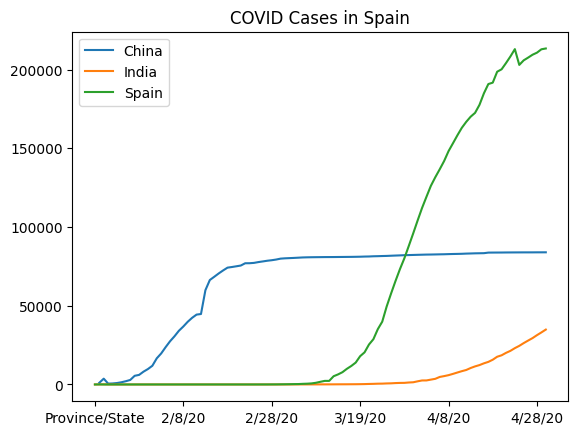

In [66]:

#visualise data related to a country
corona_datset_aggregated.loc["China"].plot(title="COVID Cases in China")
corona_datset_aggregated.loc["India"].plot(title="COVID Cases in India")
corona_datset_aggregated.loc["Spain"].plot(title="COVID Cases in Spain")
plt.legend(["China", "India", "Spain"])
plt.show()

<Axes: >

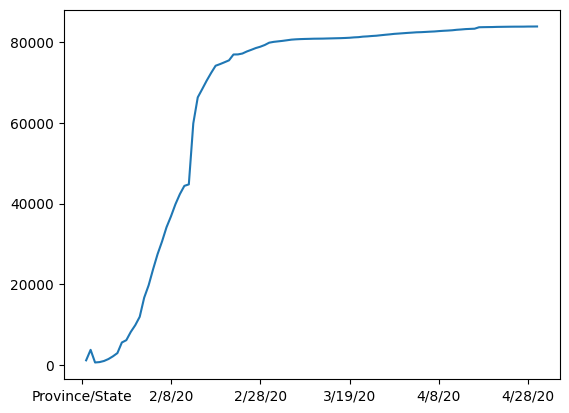

In [67]:

corona_datset_aggregated.loc["China"].plot()

<Axes: >

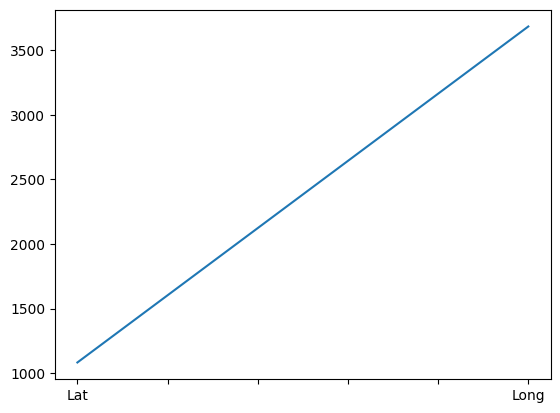

In [68]:

corona_datset_aggregated.loc["China"][:3].plot()

<Axes: >

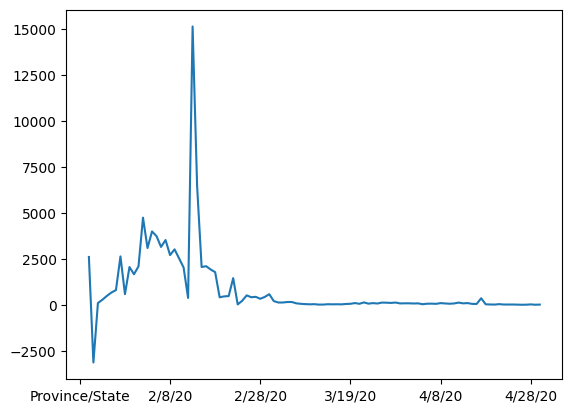

In [69]:

#calculate first derivate of the curve
corona_datset_aggregated.loc["China"].diff().plot()

In [70]:

#maximum infection rate
corona_datset_aggregated.loc["China"].diff().max()

15136.0

In [71]:

corona_datset_aggregated.loc["India"].diff().max()

1893.0

In [72]:

corona_datset_aggregated.loc["Spain"].diff().max()

9630.0

In [73]:

countries=list(corona_datset_aggregated.index)
max_infection_rates=[]


In [74]:

countries=list(corona_datset_aggregated.index)
max_infection_rates=[]

for c in countries:
    max_infection_rates.append(corona_datset_aggregated.loc[c].diff().max())
corona_datset_aggregated["Max_infection_rates"]=max_infection_rates

In [75]:
corona_datset_aggregated

,Province/State,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,...,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,Max_infection_rates
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.0,33.000000,65.000000,0,0,0,0,0,0,0,...,1176,1279,1351,1463,1531,1703,1828,1939,2171,232.000000
Albania,0.0,41.153300,20.168300,0,0,0,0,0,0,0,...,634,663,678,712,726,736,750,766,773,41.153300
Algeria,0.0,28.033900,1.659600,0,0,0,0,0,0,0,...,2910,3007,3127,3256,3382,3517,3649,3848,4006,199.000000
Andorra,0.0,42.506300,1.521800,0,0,0,0,0,0,0,...,723,723,731,738,738,743,743,743,745,43.000000
Angola,0.0,-11.202700,17.873900,0,0,0,0,0,0,0,...,25,25,25,25,26,27,27,27,27,29.076600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Bank and Gaza,0.0,31.952200,35.233200,0,0,0,0,0,0,0,...,474,480,484,342,342,342,343,344,344,66.000000
Western Sahara,0.0,24.215500,-12.885800,0,0,0,0,0,0,0,...,6,6,6,6,6,6,6,6,6,24.215500
Yemen,0.0,15.552727,48.516388,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,6,6,32.963661


In [76]:

corona_data=pd.DataFrame(corona_datset_aggregated["Max_infection_rates"])

In [77]:
corona_data

,Max_infection_rates
Country/Region,
Afghanistan,232.000000
Albania,41.153300
Algeria,199.000000
Andorra,43.000000
Angola,29.076600
...,...
West Bank and Gaza,66.000000
Western Sahara,24.215500
Yemen,32.963661


In [78]:

#importing the dataset 2
happiness_report=pd.read_csv("/content/worldwide_happiness_report.csv")

In [79]:

happiness_report

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


In [80]:

#drop useless columns
useless_cols=["Overall rank","Generosity","Perceptions of corruption"]

In [81]:
happiness_report.drop(useless_cols,axis=1,inplace=True)
happiness_report.head()

,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
0,Finland,7.769,1.340,1.587,0.986,0.596
1,Denmark,7.600,1.383,1.573,0.996,0.592
2,Norway,7.554,1.488,1.582,1.028,0.603
3,Iceland,7.494,1.380,1.624,1.026,0.591
4,Netherlands,7.488,1.396,1.522,0.999,0.557


In [82]:

happiness_report.set_index("Country or region",inplace=True)
happiness_report.head()

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Country or region,,,,,
Finland,7.769,1.340,1.587,0.986,0.596
Denmark,7.600,1.383,1.573,0.996,0.592
Norway,7.554,1.488,1.582,1.028,0.603
Iceland,7.494,1.380,1.624,1.026,0.591
Netherlands,7.488,1.396,1.522,0.999,0.557


In [83]:

corona_data.shape

(187, 1)

In [84]:

happiness_report.shape

(156, 5)

In [85]:

data= corona_data.join(happiness_report,how="inner")
data

,Max_infection_rates,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Afghanistan,232.000000,3.203,0.350,0.517,0.361,0.000
Albania,41.153300,4.719,0.947,0.848,0.874,0.383
Algeria,199.000000,5.211,1.002,1.160,0.785,0.086
Argentina,291.000000,6.086,1.092,1.432,0.881,0.471
Armenia,134.000000,4.559,0.850,1.055,0.815,0.283
...,...,...,...,...,...,...
Venezuela,66.589700,4.707,0.960,1.427,0.805,0.154
Vietnam,92.000000,5.175,0.741,1.346,0.851,0.543
Yemen,32.963661,3.380,0.287,1.163,0.463,0.143
Zambia,43.700000,4.107,0.578,1.058,0.426,0.431


In [86]:

data.corr()

,Max_infection_rates,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Max_infection_rates,1.000000,0.231240,0.251168,0.194084,0.291400,0.080686
Score,0.231240,1.000000,0.793847,0.788591,0.799893,0.587007
GDP per capita,0.251168,0.793847,1.000000,0.759468,0.863062,0.394603
Social support,0.194084,0.788591,0.759468,1.000000,0.765286,0.456246
Healthy life expectancy,0.291400,0.799893,0.863062,0.765286,1.000000,0.427892
Freedom to make life choices,0.080686,0.587007,0.394603,0.456246,0.427892,1.000000


In [87]:

data

,Max_infection_rates,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Afghanistan,232.000000,3.203,0.350,0.517,0.361,0.000
Albania,41.153300,4.719,0.947,0.848,0.874,0.383
Algeria,199.000000,5.211,1.002,1.160,0.785,0.086
Argentina,291.000000,6.086,1.092,1.432,0.881,0.471
Armenia,134.000000,4.559,0.850,1.055,0.815,0.283
...,...,...,...,...,...,...
Venezuela,66.589700,4.707,0.960,1.427,0.805,0.154
Vietnam,92.000000,5.175,0.741,1.346,0.851,0.543
Yemen,32.963661,3.380,0.287,1.163,0.463,0.143
Zambia,43.700000,4.107,0.578,1.058,0.426,0.431


<Axes: xlabel='GDP per capita', ylabel='Max_infection_rates'>

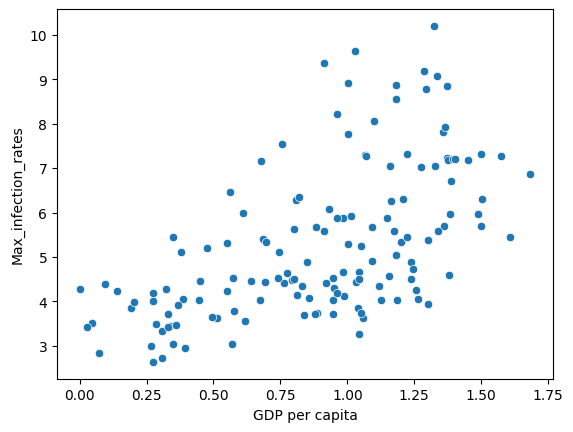

In [88]:

#visualization
x=data["GDP per capita"]
y=data["Max_infection_rates"]
sns.scatterplot(x=x, y=np.log(y))

<Axes: xlabel='GDP per capita', ylabel='Max_infection_rates'>

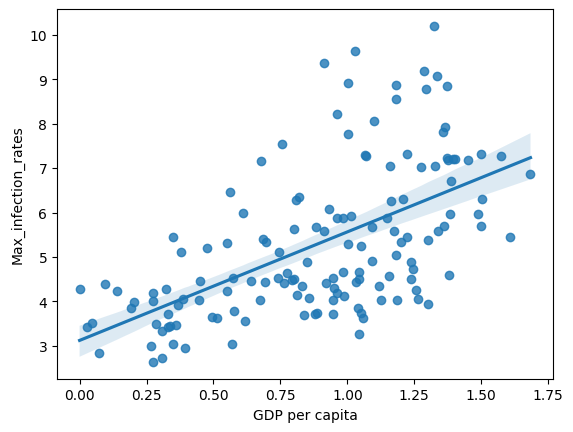

In [89]:

sns.regplot(x=x, y=np.log(y))

<Axes: xlabel='Social support', ylabel='Max_infection_rates'>

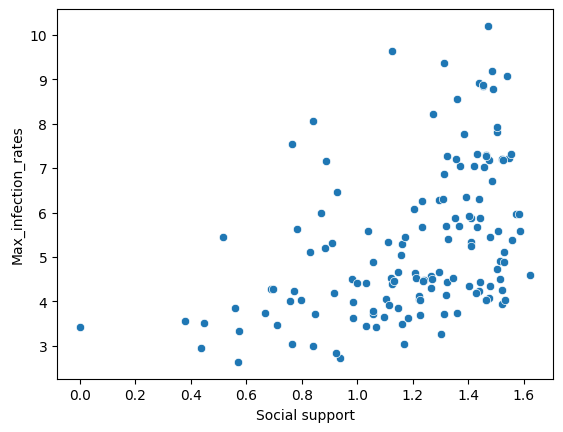

In [90]:

x=data["Social support"]
y=data["Max_infection_rates"]
sns.scatterplot(x=x, y=np.log(y))

<Axes: xlabel='Social support', ylabel='Max_infection_rates'>

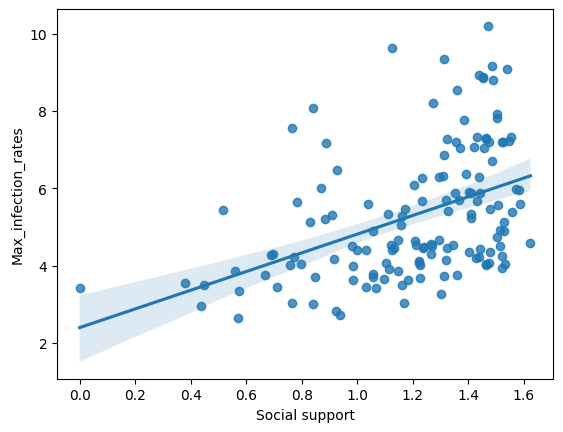

In [91]:

sns.regplot(x=x, y=np.log(y))

<Axes: xlabel='Healthy life expectancy', ylabel='Max_infection_rates'>

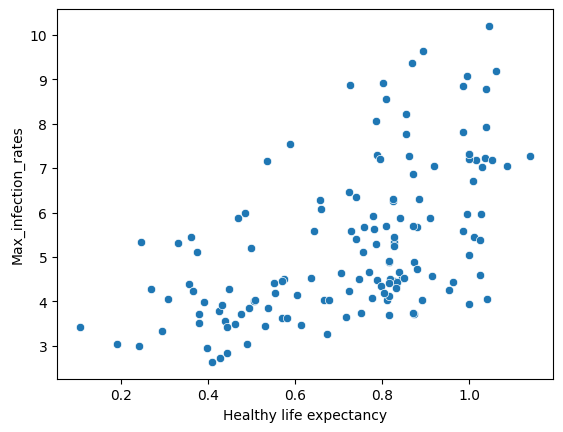

In [92]:

x=data["Healthy life expectancy"]
y=data["Max_infection_rates"]
sns.scatterplot(x=x, y=np.log(y))

<Axes: xlabel='Healthy life expectancy', ylabel='Max_infection_rates'>

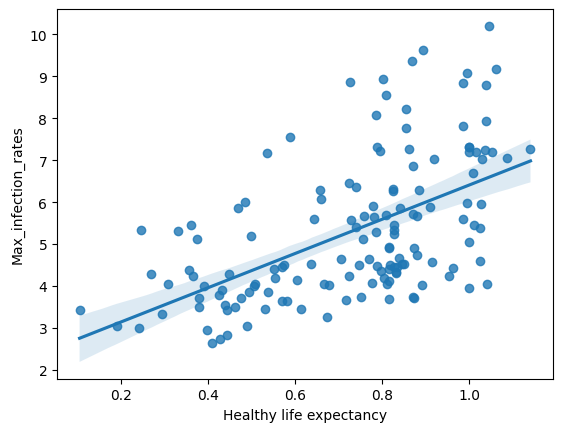

In [93]:

sns.regplot(x=x, y=np.log(y))

<Axes: xlabel='Freedom to make life choices', ylabel='Max_infection_rates'>

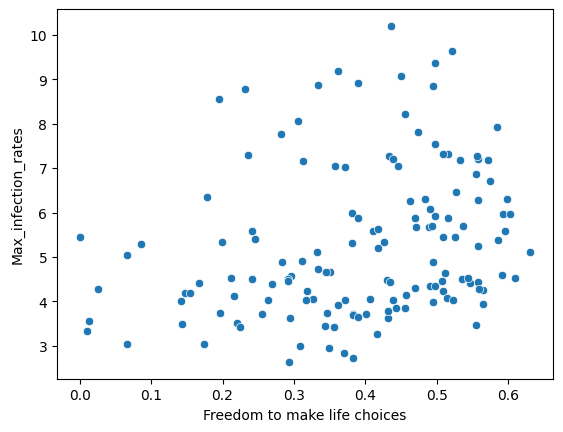

In [94]:

x=data["Freedom to make life choices"]
y=data["Max_infection_rates"]
sns.scatterplot(x=x, y=np.log(y))

<Axes: xlabel='Freedom to make life choices', ylabel='Max_infection_rates'>

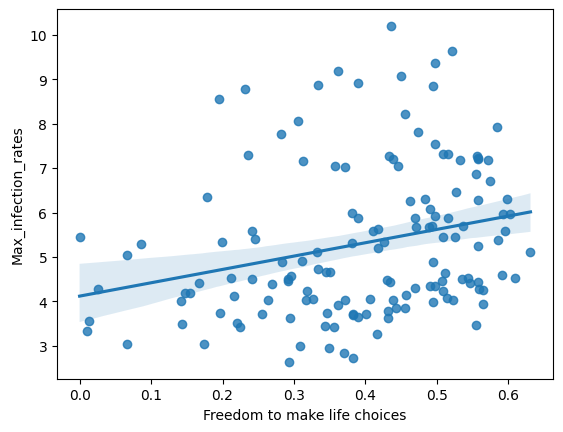

In [95]:

sns.regplot(x=x, y=np.log(y))